<a href="https://colab.research.google.com/github/sri-wahyuni10/Inter-flyrank/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Framing: Hospital Readmission Risk Prediction (Freestyle Lane)

## 1. Search Question
Is a patient who has just been discharged from the hospital at high risk for readmission within the next 30 days?

## 2. Unit of Analysis
One patient discharge event. If a patient is hospitalized twice in one year, these events are counted as two separate rows of analysis.

## 3. Output
A probability score (0 to 1) indicates the patient's risk level, which is then categorized into "High Risk" or "Low Risk" groups.

## 4. Action Someone Could Take From It
- Medical/nursing staff can provide more intensive aftercare education to families before the patient is discharged.
- Schedule follow-up appointments earlier (e.g., within the first 3 to 5 days) instead of the standard follow-up schedule.
- Conduct telehealth follow-up during the critical first week after discharge.

## 5. Cost of a Wrong Recommendation
- False Negative (Low Prediction Despite Actual High Risk): Patients are discharged without additional monitoring, experiencing worsening at home without prompt treatment, which can be fatal or lead to lawsuits against the hospital.
- False Positive (High Prediction Despite Actual Low Risk): Operational inefficiencies occur. Hospitals waste valuable medical staff time and monitoring resources on patients who are actually stable and self-sufficient.

## 6. Why Data or ML Can Help at All
Conventional patient discharge decisions often rely solely on a simple physical checklist or a doctor's subjective instincts. Machine learning can simultaneously analyze complex interactions between diagnostic history, number of laboratory procedures, prescribed medications, age, and comorbidities to produce much more accurate, objective risk predictions.

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Download latest version
path = kagglehub.dataset_download("vanpatangan/readmission-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'readmission-dataset' dataset.
Path to dataset files: /kaggle/input/readmission-dataset


In [6]:
df2 = pd.read_csv("/kaggle/input/readmission-dataset/sample_submission.csv")
df2.head()

,Patient_ID,readmitted
0,1,1
1,2,0
2,3,1
3,4,1
4,5,1


In [7]:
df = pd.read_csv("/kaggle/input/readmission-dataset/train_df.csv")
df.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [8]:
persentase_readmitted = df2['readmitted'].value_counts(normalize=True) * 100
print("Persentase Pasien Kembali Dirawat:")
print(persentase_readmitted)


Persentase Pasien Kembali Dirawat:
readmitted
0    51.4
1    48.6
Name: proportion, dtype: float64


Analysis 1: Age Distribution and Readmission Risk
readmitted          0          1
age                             
18          85.507246  14.492754
19          86.567164  13.432836
20          82.608696  17.391304
21          73.684211  26.315789
22          82.539683  17.460317
..                ...        ...
85          78.260870  21.739130
86          83.076923  16.923077
87          78.125000  21.875000
88          86.274510  13.725490
89          85.507246  14.492754

[72 rows x 2 columns]


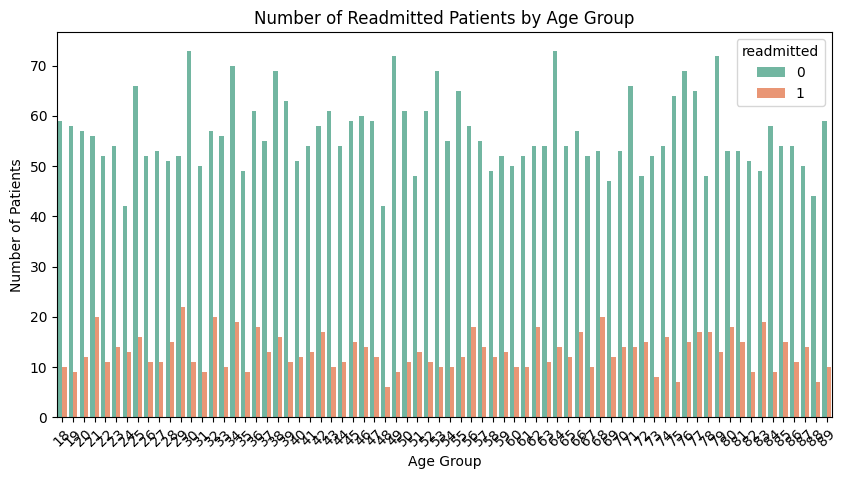

In [11]:
print("Analysis: Age Distribution and Readmission Risk")

age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
print(age_readmit)


plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='age', hue='readmitted', palette='Set2')
plt.title('Number of Readmitted Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

In [12]:
print("ANALYSIS 1: Baseline Rate (Percentage of Readmission Problems)")

print("\n[ANALYSIS 1] Calculating the Percentage of Readmission Cases in the Dataset")
if 'readmitted' in df.columns:
    rate = df['readmitted'].value_counts(normalize=True) * 100
    amount = df['readmitted'].value_counts()
    for status, persentase in rate.items():
        label = "Kembali Dirawat (1)" if status == 1 else "Safe / No Return (0)"
        print(f" -> {label}: {persentase:.2f}% ({amount[status]} pasien)")
else:
    print("Column 'readmitted' not found. Make sure you are reading the file 'train_df.csv', not sample_submission.")

print("\n[ANALYSIS 2] Comparing Averages of Numeric Columns Based on Readmission Status")
if 'readmitted' in df.columns:
    # Mengambil semua kolom bertipe angka selain Patient_ID dan readmitted
    kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
    kolom_numerik = [col for col in kolom_numerik if col not in ['Patient_ID', 'readmitted']]

    if len(kolom_numerik) > 0:
        # Menghitung rata-rata kelompok
        rerata_grup = df.groupby('readmitted')[kolom_numerik].mean()
        print(rerata_grup.T) # .T digunakan untuk membalik tabel agar lebih mudah dibaca (baris jadi kolom)
        print("\n*Conclusion Hint:* Find the column where the difference in numbers between groups 0 and 1 is the greatest.")
    else:
        print("No other numeric columns were found besides ID and Target.")
else:
    print("The target column is not available for grouping.")

print("\n[ANALYSIS 3] Finding the Relationship between Category/Text Columns and Readmission Risk")
if 'readmitted' in df.columns:
    # Mengambil kolom bertipe objek/teks/kategori
    kolom_kategori = df.select_dtypes(include=['object', 'category']).columns.tolist()

    if len(kolom_kategori) > 0:
        # Kita ambil 1 kolom kategori pertama sebagai contoh sampel analisis otomatis
        sampel_kolom = kolom_kategori[0]
        print(f"-> Analyze the first category column found: '{sampel_kolom}'")

        # Membuat tabel silang persentase
        tabel_silang = pd.crosstab(df[sampel_kolom], df['readmitted'], normalize='index') * 100
        print(tabel_silang)
    else:
        print("No column of type category/text was found in the dataset.")

ANALYSIS 1: Baseline Rate (Percentage of Readmission Problems)

[ANALYSIS 1] Calculating the Percentage of Readmission Cases in the Dataset
 -> Safe / No Return (0): 81.20% (4060 pasien)
 -> Kembali Dirawat (1): 18.80% (940 pasien)

[ANALYSIS 2] Comparing Averages of Numeric Columns Based on Readmission Status
readmitted                 0          1
age                53.283005  53.368085
num_procedures      4.464778   4.444681
days_in_hospital    7.415517   7.314894
comorbidity_score   2.069458   2.064894

*Conclusion Hint:* Find the column where the difference in numbers between groups 0 and 1 is the greatest.

[ANALYSIS 3] Finding the Relationship between Category/Text Columns and Readmission Risk
-> Analyze the first category column found: 'gender'
readmitted          0          1
gender                          
Female      80.587535  19.412465
Male        81.821846  18.178154


FIGURE 1: Percentage of Target Distribution (Readmitted vs Secured)

FIGURE 2: Risk Analysis by Gender


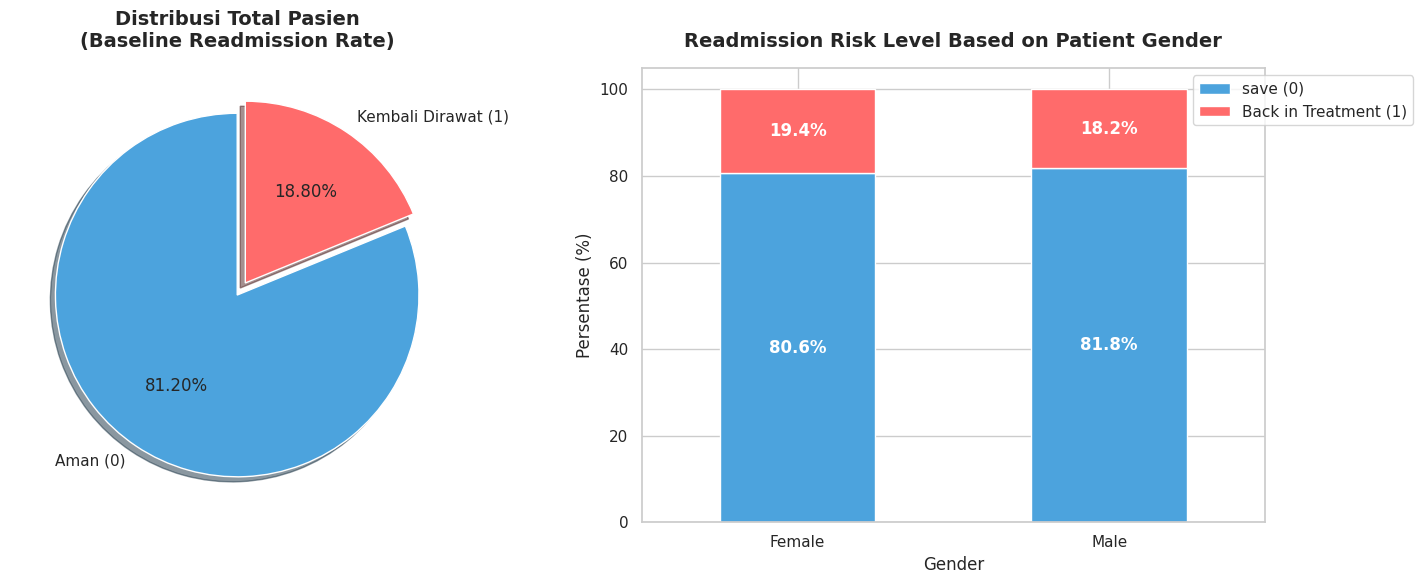

In [13]:
# Mengatur tema visualisasi agar bersih dan modern
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# Membuat canvas/area grafik berjejer (1 baris, 2 kolom)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

print("FIGURE 1: Percentage of Target Distribution (Readmitted vs Secured)")
status_counts = df['readmitted'].value_counts()
labels = ['Aman (0)', 'Kembali Dirawat (1)']
colors = ['#4ca3dd', '#ff6b6b'] # Biru tenang dan Merah soft

ax[0].pie(status_counts, labels=labels, autopct='%1.2f%%', startangle=90,
          colors=colors, explode=(0, 0.08), shadow=True)
ax[0].set_title('Distribusi Total Pasien\n(Baseline Readmission Rate)', fontsize=14, fontweight='bold', pad=15)

print("\nFIGURE 2: Risk Analysis by Gender")
gender_data = pd.crosstab(df['gender'], df['readmitted'], normalize='index') * 100

gender_data.plot(kind='bar', stacked=True, color=colors, ax=ax[1])
ax[1].set_title('Readmission Risk Level Based on Patient Gender', fontsize=14, fontweight='bold', pad=15)
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Persentase (%)', fontsize=12)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].legend(['save (0)', 'Back in Treatment (1)'], loc='upper right', bbox_to_anchor=(1.25, 1))

# Memberikan label angka langsung di dalam batang grafik Gender
for p in ax[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0: # Hanya tulis angka jika batangnya ada isinya
        ax[1].annotate(f'{height:.1f}%', (x + width/2, y + height/2),
                       ha='center', va='center', color='white', fontweight='bold')

# Menyesuaikan tata letak agar tidak terpotong
plt.tight_layout()
plt.show()

## Conclusion & Justification for Lane Selection (Lane Justification)

Based on the initial data exploration (EDA) conducted, I fully support the selection of the **Freestyle Lane: Hospital Readmission Risk Prediction**, based on the following three concrete facts:

1. **Severity of the Problem (Baseline Rate):** 18.80% (940 patients)** of the total dataset population were readmitted within 30 days. This figure is quite high and demonstrates that this service inefficiency is a real problem that requires a predictive solution.

2. **Weaknesses of the Linear/Manual Rule:** Based on the averages of numerical variables such as age (53 years), number of procedures (4.4), length of stay (7.3 days), and comorbidity score (2.0), the characteristics of patients who were readmitted (1) and those who were not (0) appear very similar to the naked eye. This demonstrates that a manual rule or simple linear cutoff will not be able to distinguish between these two groups. A non-linear machine learning model is needed to discover hidden patterns between the columns.

3. **Demographic Factors (Gender):** The data shows a slight difference in risk based on gender, with **Female patients having a higher readmission rate of 19.41%** compared to male patients at 18.17%.

**Final Conclusion:** Because the differences between patients are very small in simple descriptive statistics, a Machine Learning approach is crucial to combine all 17 available features to enable hospitals to accurately detect high-risk patients before they are discharged.